# Magnetostatic 2D linear

## Setup

### Path setup

In [43]:
import os

In [44]:
path_to_this_folder = os.getcwd() # Do it before calling %cd ../.. so that the path is accurate

### Project setup

In [45]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # Prevent internal ngsolve imports from killing the kernel


### Imports

Usual libraries

In [46]:
import tomllib
from time import time
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from ngsolve import Mesh, H1, BilinearForm, LinearForm, GridFunction, dx, grad, InnerProduct, Integrate, CF, exp
from netgen.read_gmsh import ReadGmsh

import numpy as np



NeuROM-optim, our in-house library

In [47]:
from neurom_optim.Pre_processing.process_hardware import get_precision, get_device
from neurom_optim.Pre_processing.process_gmsh import read_gmsh, get_nodes_and_elements_IDs
from neurom_optim.FENN.VertexNN.FEENN_2D.FEENN import FEENN_2D
from neurom_optim.FENN.VertexNN.FEENN_2D.Element import Tri_2D_lin
from neurom_optim.FENN.VertexNN.FEENN_2D.Mapping import Mapping_2D_Affine
from neurom_optim.FENN.ConstantNN.constantNN import ConstantNN
from neurom_optim.FENN.L2NN.field_L2NN import Field_L2NN
from neurom_optim.PropertiesNN.PropertiesNN import PropertiesNN
from neurom_optim.Pre_processing.build_solver import build_solver
from neurom_optim.PDE.optim_2D import Optim_2D_loss
from neurom_optim.PDE.operators import curl
from neurom_optim.PDE.magnetostatic_2D import Magnetostatic_2D
from neurom_optim.MaterialNN.BinarySelection import BinarySelection
from neurom_optim.Baselines.Poisson_2D.Uniform.baseline import baseline
from neurom_optim.Post_processing.VTKExport.export_vtk import export_vtk
from neurom_optim.MaterialNN.NL_nu_altair import NL_nu_altair
from neurom_optim.PDE.magnetostatic_2D_NL import Magnetostatic_2D_NL

from neurom_optim.Baselines.Magnetostatic_2D.NL.inductance_ngsolve import meshInductance, solve



### Number precision

In [48]:
IntPrecision = torch.int32
FloatPrecision = torch.float64

### Hardware

Note that for cases of small meshes cpu outperforms gpu

In [49]:
device = 'cpu'

# Focusing on the geometry of the problem

In this toy example, the problem is considered in a simple 2D case, where the part in blue is iron and the rest is air. 

In [50]:
interior_dim = 2
boundary_dim = 1

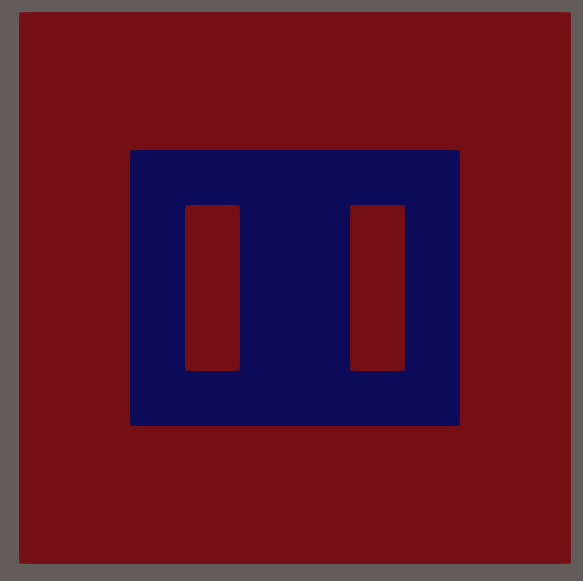

A slice of a coil is considered, where the center of each coil parts have respectively a positive and negative imposed vector potential value for simulating a magnetic flux. The geometry is registered in the following .msh file.

In [51]:
path_to_msh = os.path.join(path_to_this_folder, "Coil_TC.msh")

The geometry can now be loaded and parsed with the neurom_optim parser

In [52]:
gmsh_mesh = read_gmsh(path_to_msh = path_to_msh,
                      IntPrecision = IntPrecision,
                      FloatPrecision = FloatPrecision)

Nodes = gmsh_mesh.nodes
connectivity = gmsh_mesh.elements[str(interior_dim)]['connectivity']

Processing GMSH file: 100%|██████████| 7984/7984 [00:00<00:00, 238449.16it/s]


# Focusing on the physics-related aspect of the problem

Helmholtz decomposition paired to Maxwell's equation states that the magnetic induction is a field that derives from a vector potential $\overrightarrow{A}\in H\left(\overrightarrow{\text{curl}},\Omega\right)$ such that
$$
\overrightarrow{B}=\overrightarrow{\text{curl}}\left(\overrightarrow{A}\right)
$$

Additionnally, the magnetic excitation is linked to the magnetic induction through the media's physics. In the considered case the physics is non-linear according to
$$
\overrightarrow{H}=\nu\left(\overrightarrow{B}\right)\overrightarrow{B}
$$
Where $\nu$ is a media related quantity known as reluctivity (or magnetic resistivity). More on $\nu$ will be done in the media definition part.

The magnetic energy can be written in term of the vector potential as :
$$
\mathcal{E}_\text{mag}\left(\overrightarrow{A}\right) = \frac{1}{2}\int_\Omega \nu\left\{\overrightarrow{\text{curl}}\left(\overrightarrow{A}\right)\right\}\cdot \overrightarrow{\text{curl}}\left(\overrightarrow{A}\right)\cdot\overrightarrow{\text{curl}}\left(\overrightarrow{A}\right)\text{d}\Omega
$$

Hence, the first step into modelling the magnetic energy is to define a proper vector potential. In the consider problem, the vector potential has the following constrains :
$$
\begin{align*}
&\overrightarrow{A} = A(x)\overrightarrow{e}_z&&\forall x\in \Omega\\
&\overrightarrow{A}(x^+)\cdot \overrightarrow{e}_z=A_0\\
&\overrightarrow{A}(x^-)\cdot \overrightarrow{e}_z = -A_0\\
&\overrightarrow{A}(x) = \overrightarrow{0}&&\forall x\in\partial \Omega\\
\end{align*}
$$ 

In [53]:
n_components = 1

dirichlet_exterior = {'entity_name'         : 'Exterior',
                        'Value'              : 0}

dirichlet_positive_source = {'entity_name'                       : 'Positive_source',
                            'entity_dim'                         : 0,
                            'Value'                              : 1/100 }

dirichlet_negative_source = {'entity_name'                       : 'Negative_source',
                            'entity_dim'                         : 0,
                            'Value'                              : -1/100}

dirichlet_config = [dirichlet_exterior, dirichlet_positive_source, dirichlet_negative_source]

In a practicle setting, $\overrightarrow{A}$ is approximated through a finite element scheme. Here we use a triangle mesh with pointwise linear interpolation (Lagrange P1). Therefore, $\mathcal{E}_{mag}$ is expressed through the integration of a constant by element field, which can be computed exactly using an order 1 Gauss quadrature.

In [54]:
quadrature_order = 1

This can directly be built using neurom_optim 

In [55]:
# Build the field candidate. Here we use a linear interpolation scheme.
A = FEENN_2D(Nodes = Nodes,
            connectivity=connectivity,
            n_components=1,
            element=Tri_2D_lin(IntPrecision=IntPrecision, FloatPrecision=FloatPrecision),
            mapping = Mapping_2D_Affine(),
            IntPrecision=IntPrecision,
            FloatPrecision=FloatPrecision)

# Apply dirichlet
for dirichlet in dirichlet_config:

    nodeIDs, _ = get_nodes_and_elements_IDs(gmsh_mesh=gmsh_mesh,
                                            entity_dim = dirichlet.get('entity_dim', 1),
                                            entity_name = dirichlet.get('entity_name', None),
                                            entity_tag = dirichlet.get('entity_tag', None))
    
    
    value = dirichlet['Value']*torch.ones_like(nodeIDs, dtype = FloatPrecision).unsqueeze(-1)

    A.SetBCs(Fixed_nodal_coordinates_Ids = nodeIDs,
            Fixed_nodal_values_Ids = nodeIDs,
            Fixed_nodal_values_values = value)
    

# Specify the integration scheme
A.SetQuad(quadrature_order = quadrature_order)
A.Freeze(freeze_grid=True, freeze_interpolation=False)

# Move the object to the chosen hardware
A.to(device)

# Specify that A should store its evolution so that we can export it to vtk
A.StoreResults()

## Modelling the media

The reluctivity $\nu$ directly depends on the media's compositon. In the case at hand $\nu(x)$ can either be iron or air. In the linear case, both can be viewed as constants.

In [56]:
nu_air  = 1/(4*np.pi*1e-7)
nu_iron = 1/(4*np.pi*1e-7*5000)

The choice of putting iron or not around a point $x$ is encoded by a choice variable $\rho$ defined by
$$
\begin{align*}
\;\rho :& \Omega\mapsto \{0,1\}\\
&x\mapsto \left\{\begin{array}{cc}1&\text{if the media is made of iron in $x$}\\0&\text{if the media is made of air in $x$}\end{array}\right.
\end{align*}
$$

In [57]:
# Define the nu_0 property
nu_0 = ConstantNN(property_value=nu_air,
                    IntPrecision = IntPrecision,
                    FloatPrecision = FloatPrecision)

# nu_0 is not a field to be found
nu_0.setBCs(is_fixed=True)

# Define the nu_1 property
nu_1 = ConstantNN(property_value=nu_iron,
                    IntPrecision = IntPrecision,
                    FloatPrecision = FloatPrecision)

# nu_1 is not a field to be found
nu_1.setBCs(is_fixed=True)


# Define the nu property using nu_0 and nu_1
# BinarySelection.forward(el_ids, NPoints, *args, **kwargs) -> (1-choice)*self.properties['property_1'](el_ids, NPoints, *args, **kwargs) + choice*self.properties['property_2'](el_ids, NPoints, *args, **kwargs)
# nu = BinarySelection(property_1     = nu_0,
#                     property_2     = nu_1,
#                     NElem          = len(connectivity),
#                     IntPrecision   = IntPrecision,
#                     FloatPrecision = FloatPrecision)

nu = BinarySelection(property_1     = nu_0,
                    property_2     = nu_1,
                    NElem          = len(connectivity),
                    IntPrecision   = IntPrecision,
                    FloatPrecision = FloatPrecision)

# Set the value of nu to nu_0 in "domain_no_coil"
# BinarySelection.setBCs <=> select and fix the value of the "choice" variable (see BinarySelection.forward)
_, elemIDs = get_nodes_and_elements_IDs(gmsh_mesh=gmsh_mesh,
                                            entity_dim=2,
                                            entity_name = 'domain_no_coil')

nu.setBCs(Fixed_Ids=elemIDs, specific_value=torch.zeros_like(elemIDs))

# Set the value of nu to nu_0 in "coil_1"
# BinarySelection.setBCs <=> select and fix the value of the "choice" variable (see BinarySelection.forward)
_, elemIDs = get_nodes_and_elements_IDs(gmsh_mesh=gmsh_mesh,
                                            entity_dim=2,
                                            entity_name = 'coil_1')

nu.setBCs(Fixed_Ids=elemIDs, specific_value=torch.zeros_like(elemIDs))

# Set the value of nu to nu_0 in "coil_2"
# BinarySelection.setBCs <=> select and fix the value of the "choice" variable (see BinarySelection.forward)
_, elemIDs = get_nodes_and_elements_IDs(gmsh_mesh=gmsh_mesh,
                                            entity_dim=2,
                                            entity_name = 'coil_2')

nu.setBCs(Fixed_Ids=elemIDs, specific_value=torch.zeros_like(elemIDs))


# Set the value of nu to nu_1 in "core"
# BinarySelection.setBCs <=> select and fix the value of the "choice" variable (see BinarySelection.forward)
_, elemIDs = get_nodes_and_elements_IDs(gmsh_mesh=gmsh_mesh,
                                            entity_dim=2,
                                            entity_name = 'core')

nu.setBCs(Fixed_Ids=elemIDs, specific_value=torch.ones_like(elemIDs))

# The only problem-relevant material property is nu
Mat = PropertiesNN(dim = interior_dim,
                NElem = len(connectivity),
                IntPrecision = IntPrecision,
                FloatPrecision = FloatPrecision)

Mat.add_property(property_name = 'nu',
                property = nu)

# Move the object to the chosen hardware
Mat.to(device)

PropertiesNN(
  (properties): ModuleDict(
    (nu): BinarySelection(
      (soft_choice): ParameterDict(
          (free): Parameter containing: [torch.DoubleTensor of size 0]
          (imposed): Parameter containing: [torch.DoubleTensor of size 5172]
      )
      (properties): ModuleDict(
        (property_1): ConstantNN()
        (property_2): ConstantNN()
      )
      (sigmoid): Sigmoid()
    )
  )
)

# Objective

## Variationnal formulation

$$
\begin{align*}
\;&\text{Find}&&\overrightarrow{A}\\
&\text{s.t}&&\int_{\Omega}\nu \overrightarrow{\text{curl}}\left(\overrightarrow{A}\right)\overrightarrow{\text{curl}}\left(\overrightarrow{A}^*\right)\text{d}\Omega,\quad \forall \overrightarrow{A}^*\in H^0\left(\overrightarrow{\text{curl}},\Omega\right)
\end{align*}
$$

$$
\begin{align*}
\;&\text{Find}&&\overrightarrow{A}\\
&\text{s.t}&&\left.\frac{\text{d}}{\text{d}}\right|_{\epsilon = 0}\mathcal{E}_{\text{mag}}(\overrightarrow{A}+\epsilon\overrightarrow{A}^*)=0,\quad\forall \overrightarrow{A}\in H^0\left(\overrightarrow{\text{curl}},\Omega\right)
\end{align*}
$$

This is solved with NGSolve to get a baseline

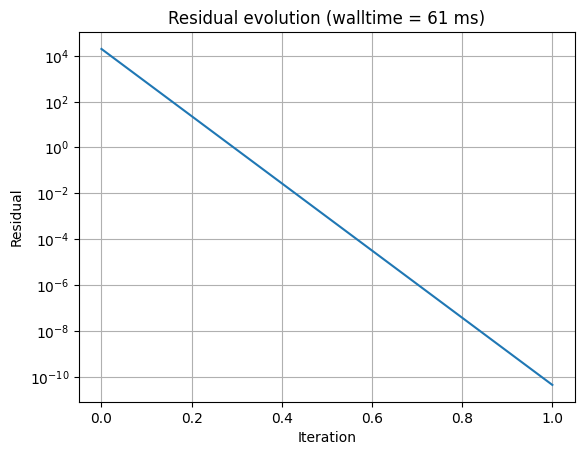

In [58]:
baseline_mesh = meshInductance(meshsize_factor = 0.5)
def solveMagnetostatics(a0 : GridFunction,
                        nu : callable = lambda b : 1/(4e-7 * np.pi),
                        solver : str = "sparsecholesky"):
    
    """ Solve the magnetostatic problem """

    R = CF(((0,1),(-1,0)), dims = (2,2))
    Curl = lambda x : R * grad(x)

    residual = lambda u, v : Curl(v) * (nu(Curl(u)) * Curl(u)) * dx
    result = solve(a0.space, residual, initial_guess = a0, solver = solver)
    return result

B_avg = 1
# l = (Integrate(1, baseline_mesh)**(0.5))/3
# phi = 1*l

fes = H1(baseline_mesh, order=1, dirichlet = "out", dirichlet_bbnd = 'xP|xM')
a0 = GridFunction(fes)
# a0.vec.data[0] = phi/2
# a0.vec.data[1] = -phi/2


a0.vec.data[0] = dirichlet_positive_source['Value']
a0.vec.data[1] = dirichlet_negative_source['Value']


def myNu(b):
    global nu_0_value, nu_1_value
    return  baseline_mesh.MaterialCF({"core" : nu_iron}, default = nu_air)

dicoSol = solveMagnetostatics(a0, nu = myNu)
baseline = dicoSol["solution"]

plt.semilogy(dicoSol["residual"])
plt.xlabel("Iteration")
plt.ylabel("Residual")
plt.title(f'Residual evolution (walltime = {1000 * dicoSol["wall_time"]:.0f} ms)')
plt.grid()
plt.show()

## Least action

The least action principle states that solving the problem is the same as minimizing the action functionnal. In this case the action is just the magnetic energy. Hence, the problem is 

$$
\begin{align*}
\;&\text{Find}&&\overrightarrow{A}^*=\arg \min_{\overrightarrow{A}\in\mathcal{A}} \mathcal{E}_{mag}\left(\overrightarrow{A}\right)
\end{align*}
$$


In [59]:
vtk_export_config = {'path_to_folder'       : os.path.join(os.path.join(path_to_this_folder, 'Results'), 'VTK_exports'),
                    'cell_data'             : ['B', 'potential', 'j', 'field_term', 'source_term', 'nu', 'mapping_det'],
                    'point_data'            : ['A'],
                    'export_vtk'            : True}

energy_functionnal = Magnetostatic_2D_NL(IntPrecision=IntPrecision, 
                                        FloatPrecision=FloatPrecision,
                                        vtk_export = vtk_export_config,
                                        baseline = baseline, 
                                        baseline_mesh=baseline_mesh
                                        )

In [60]:
solver_config = {'optimizer'               :  'lbfgs',
            'n_epochs'                :  500,
            'loss_decrease_c'         :   1e-13,
            'freeze_grid'             :   True,
            'freeze_interpolation'    :   False,
            'freeze_Mat'              :   True}

solver = build_solver(solver_config = solver_config,
                      loss = energy_functionnal,
                      model = A,
                      Mat = Mat)

solver.solve()

Solving (worse case scenario):  47%|████▋     | 236/500 [02:21<02:00,  2.19it/s, time=141] 

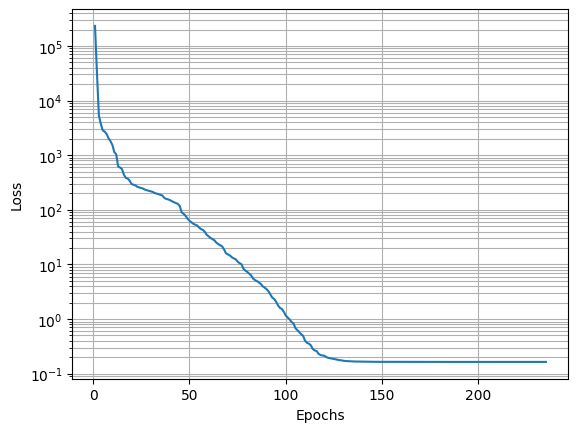

In [61]:
epochs, loss = solver.get_metric()

# Define the path to the main plot save folder
save_folder = os.path.join(os.path.join(path_to_this_folder, 'Results'), 'Plots')
os.makedirs(save_folder, exist_ok=True)

# Plot and save the loss evolution
save_name = f"loss.png"
save_path = os.path.join(save_folder, save_name)
plt.clf()
plt.plot(epochs, loss)
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, which='both')
plt.savefig(save_path)

See the rest of the results by viewing the VTK files with paraview